# Classification of Movie genres using different text features

In this notebook, we experiment with different classificaiton algorithms, in order to predict the genre of a movie. In this exercise, we only consider the genres `War`, `Animation` and `Music` as possible movie genres.

In the first phase of this exercise, we will only use the `overview` feature to predict the `genre` feature. We will try to feature extraction techniques:
- A classic Tf-Idf approach
- An embeddings-based approach, by using pretrained embedding models, namely the `Word2Vec` model

In the second phase, we will pick the best performing classifiers and train our models with more features.

It is important to state that models were used with their default parameters, since based on the evaluation metrics we got good results. If someone want to achieve better performance, he can simply do some hyperparameter tuning in the best models obtained from the first two phases of the experiment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Data loading and basic preprocessing of the relative features

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
PATH = '/content/drive/MyDrive/mining/data'

In [4]:
df = pd.read_csv(PATH+'/movies_metadata.csv')
df.info()

/tmp/ipython-input-2770860547.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH+'/movies_metadata.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [5]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


We will initialy only consider `overview` and `genres` to build some baseline models, later we will build models using more of the features.

In [6]:
columns = ['id', 'genres', 'budget', 'overview', 'popularity',  'revenue', 'runtime', 'vote_average', 'vote_count']
data = df[columns].copy()
data.head()

,id,genres,budget,overview,popularity,revenue,runtime,vote_average,vote_count
0,862,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",30000000,"Led by Woody, Andy's toys live happily in his ...",21.946943,373554033.0,81.0,7.7,5415.0
1,8844,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",65000000,When siblings Judy and Peter discover an encha...,17.015539,262797249.0,104.0,6.9,2413.0
2,15602,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",0,A family wedding reignites the ancient feud be...,11.7129,0.0,101.0,6.5,92.0
3,31357,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",16000000,"Cheated on, mistreated and stepped on, the wom...",3.859495,81452156.0,127.0,6.1,34.0
4,11862,"[{'id': 35, 'name': 'Comedy'}]",0,Just when George Banks has recovered from his ...,8.387519,76578911.0,106.0,5.7,173.0


We create the function `acquire_data` to preprocess the `genres` column and keep only the data we need, in our initial approach only `overview` and `genres`.

In [9]:
from ast import literal_eval

def acquire_data(data: pd.DataFrame, genres: list[str]):
    data = data[['id', 'overview', 'genres']].copy()
    data.loc[:, 'genres'] = data['genres'].apply(literal_eval)
    data.loc[:, 'genres'] = data['genres'].apply(lambda genre_list: [dictionary.get('name') for dictionary in genre_list])
    data = data.explode('genres')
    data = data[data['genres'].isin(genres)]
    data = data[data.groupby('id')['genres'].transform('nunique')==1]

    return data[['overview', 'genres']].dropna()

In [10]:
data_init = acquire_data(data, ['War', 'Animation', 'Music'])
data_init.head()

,overview,genres
0,"Led by Woody, Andy's toys live happily in his ...",Animation
12,An outcast half-wolf risks his life to prevent...,Animation
40,Shakespeare's Play transplanted into a 1930s s...,War
47,History comes gloriously to life in Disney's e...,Animation
61,"In 1965, passionate musician Glenn Holland tak...",Music


We now split our dataset into train and test, using the `train_test_split` method from sklearn.

In [11]:
from sklearn.model_selection import train_test_split

data_init_np = data_init.to_numpy()
X, y = data_init_np[:, 0], data_init_np[:, 1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(3704,) (3704,) (926,) (926,)


## Models to experiment with

We will experiment with some foundational models, like Decision Trees, K-Neirest Neighbors, Logistic Regression, SVM and MLP. We will use the default parameters in the baseline phase, and we will improve them later on.

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

In [13]:
seed = np.random.seed(42) # set for reproducibility of the results

clfs = [
    DecisionTreeClassifier(random_state=seed),
    KNeighborsClassifier(),
    LogisticRegression(random_state=seed),
    LinearSVC(random_state=seed),
    MLPClassifier(random_state=seed)
]

## Metrics

As metrics, in the cross validation step, we will use `accuracy` as an scoring metric for the validation sets. For the test data, we will use `accuracy`, `precision`, `recall`  and a `confusion matrix` for visualization purposes.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrices(fitted_clfs, X_test=X_test):
  fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(20,12))
  axs_flat = axs.flatten()

  for idx, clf in enumerate(fitted_clfs):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(y_pred=y_pred, y_true=y_test)

    clf_model = clf.named_steps['clf']
    if hasattr(clf_model, 'classes_'):  # decision tree problem
      display_labels = clf_model.classes_
    else:
      display_labels = clf_model.labels_

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels
    )
    disp.plot(ax=axs_flat[idx])
    axs_flat[idx].set_title(f'Model: {clf_model.__class__.__name__}')

def evaluate_classifiers(classifiers, X_test=X_test, y_test=y_test):
  scores_dict = {
      'model': [],
      'accuracy': [],
      'precision': [],
      'recall': []
  }

  for clf in classifiers:
    y_pred = clf.predict(X_test)

    scores_dict['model'].append(clf.named_steps['clf'].__class__.__name__)
    scores_dict['accuracy'].append(accuracy_score(y_pred=y_pred, y_true=y_test))
    scores_dict['precision'].append(precision_score(y_pred=y_pred, y_true=y_test, average='micro'))
    scores_dict['recall'].append(recall_score(y_pred=y_pred, y_true=y_test, average='micro'))

  return pd.DataFrame(scores_dict).sort_values(by='accuracy', ascending=False)

## Experiment related utility functions

Functions that help us run our experiments in an automated way. A `Pipeline` is the prefered way to run experiments and models, since it abstracts some detail and prevents mistakes such as data leakage.

In [16]:
def _classifier_cv(classifier, preprocessor, X_train=X_train, y_train=y_train):
  pipeline = Pipeline([
      ('preprocessor', preprocessor),
      ('clf', classifier)
  ])

  cv_score = cross_val_score(
    estimator=pipeline,
    X=X_train,
    y=y_train,
    cv=5
  )

  return cv_score, np.mean(cv_score)

def classifiers_cv_scores(preprocessor, clfs=clfs, X_train=X_train, y_train=y_train):
  for clf in clfs:
    clf_cv_score, clf_cv_mean_score = _classifier_cv(clf, preprocessor, X_train, y_train)
    print(f'{clf.__class__.__name__} 5-fold cv score: {clf_cv_score}, mean score: {clf_cv_mean_score}')


def train_classifiers(preprocessor, classifiers=clfs, X_train=X_train, y_train=y_train):
  fitted_clfs = []

  for clf in classifiers:
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', clf)
    ]).fit(X_train, y_train)
    fitted_clfs.append(pipeline)

  return fitted_clfs

## Feature extraction using TfIdfVectorizer

In this step, we will create features using the `TfIdfVectorizer`. We set `max_features` to $5000$ and also remove stopwords by passing into `stopwords` the option 'english' (list containing english stop words). We instanciate our vectorizer, but we do not fit our train data yet.


We first run a 5-fold K-validation by using the train data. We train each classifier on 4 folds and evauluate its performance on the last fold (validation set). We do this 5 times for each classifier, in order to avoid overfitting and be more condident about the classifiers performance, even before trying it to the test data we kept out of the training step.

After the cross validation is complete and we get a first look in the performance, we train our models by using all the available training data and we evaluate them by using the test data.

If the classifier performance in the validation data and in the test data is similar, we are certain that we have not overfitted our models.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

classifiers_cv_scores(vectorizer)

DecisionTreeClassifier 5-fold cv score: [0.73414305 0.73684211 0.7611336  0.72064777 0.74864865], mean score: 0.7402830360725098
KNeighborsClassifier 5-fold cv score: [0.78272605 0.77462888 0.77462888 0.73819163 0.73648649], mean score: 0.7613323850165955
LogisticRegression 5-fold cv score: [0.86099865 0.85155196 0.88124157 0.8582996  0.86891892], mean score: 0.8642021373600322
LinearSVC 5-fold cv score: [0.85964912 0.8582996  0.86639676 0.8488529  0.86081081], mean score: 0.8588018382755225
MLPClassifier 5-fold cv score: [0.83670715 0.85020243 0.86504723 0.84210526 0.85405405], mean score: 0.8496232264653317


From the 5-fold cross validation, we see that `DecisionTreeClassifier` and `KNeighborsClassifier` perform significantly worse than the other classifiers in the current scenario. The two classifiers we will consider for building our final model are the `LinearSVC` and the `LogisticRegression`.

Now, let's train our classifiers using all the available training data and see how they perform in the test data.

In [19]:
fitted_classifiers = train_classifiers(vectorizer)
evaluate_classifiers(fitted_classifiers)

,model,accuracy,precision,recall
2,LogisticRegression,0.854212,0.854212,0.854212
3,LinearSVC,0.850972,0.850972,0.850972
4,MLPClassifier,0.839093,0.839093,0.839093
1,KNeighborsClassifier,0.761339,0.761339,0.761339
0,DecisionTreeClassifier,0.726782,0.726782,0.726782


We see that there is an exact match in the ranking of the models based on accuracy. If this was not the case, and let's say the KNeighborsClassifier performed the best in the test data, we should not pick this model to move forward, because we introduce bias by picking the best performing model in the test data.

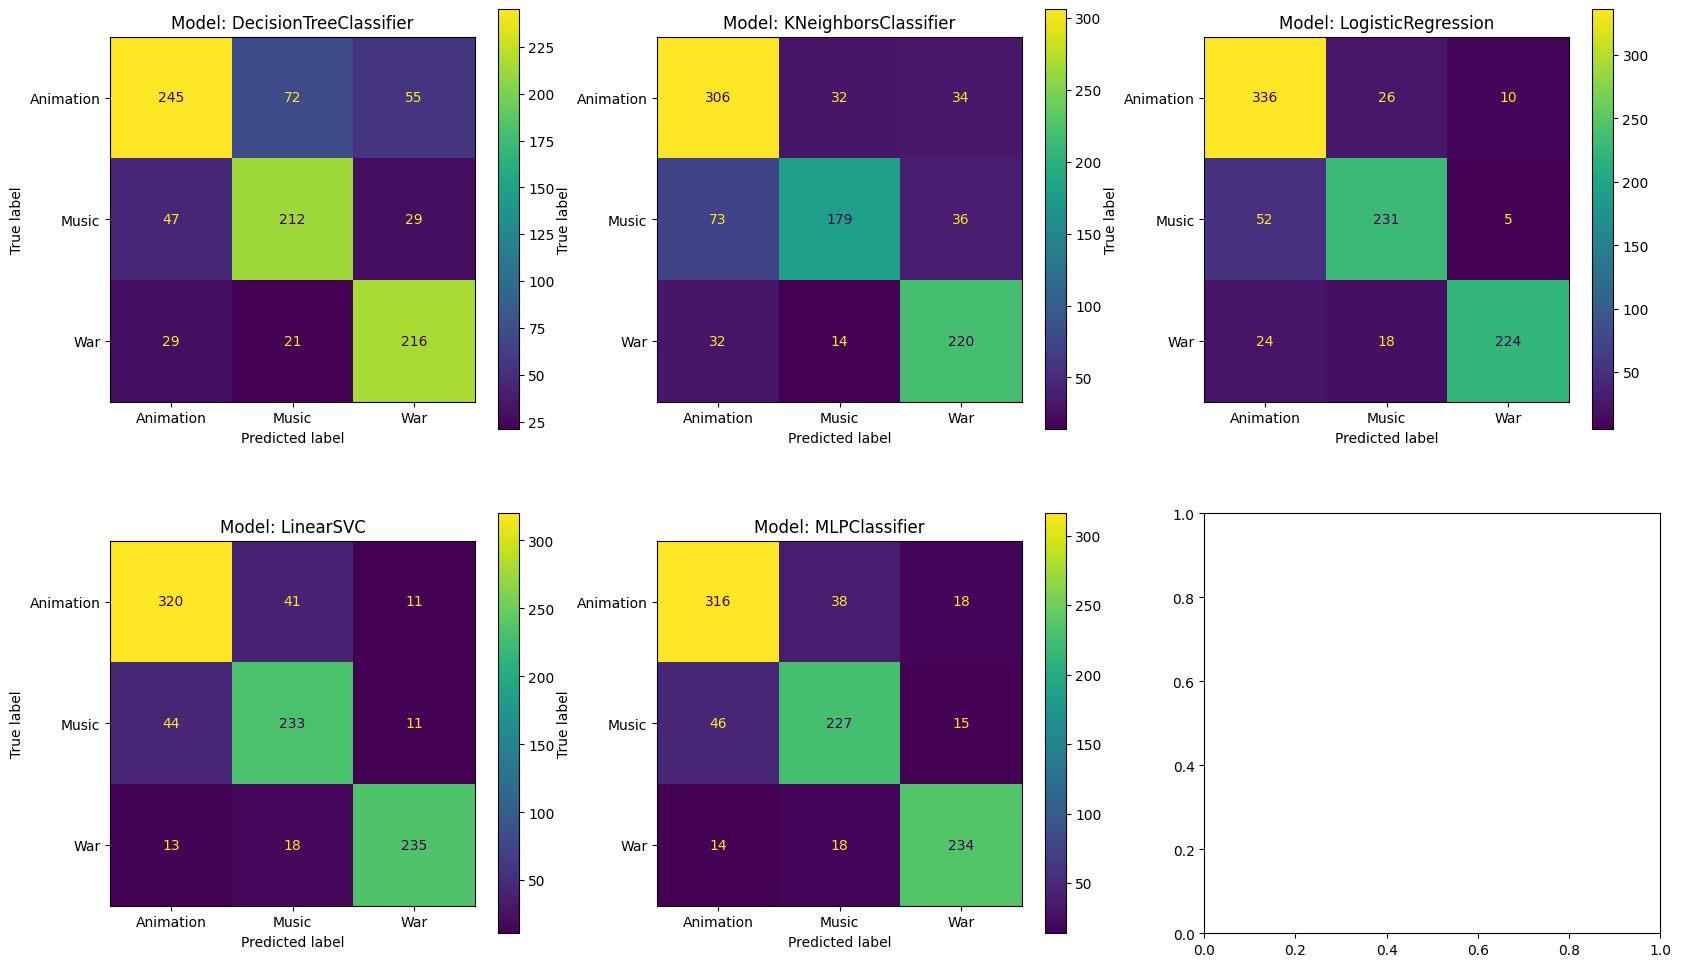

In [20]:
plot_confusion_matrices(fitted_classifiers)

## Feature extraction using the word2vec-google-news-300 pretrained model

In [21]:
! pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.8 MB/s eta 0:00:00


Our first step is to download the pretrained model we will use, feel free to skip this and just look at the results, since it is a quite large model (approx. 1.6 GB as a compressed file)

In [22]:
import gensim.downloader as gensim_api

pretrained_w2v = gensim_api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [23]:
pretrained_w2v

In [24]:
from sklearn.base import BaseEstimator, TransformerMixin

class Word2VecVectorizer(BaseEstimator, TransformerMixin):

    def __init__(self, model):
        self.model = model
        self.vector_size = model.vector_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return np.array([self._get_mean_vector(document) for document in X])

    def _get_mean_vector(self, document):
        words = document.lower().split()
        vectors = [self.model[word] for word in words if word in self.model]
        if len(vectors) == 0:
            return np.zeros(self.vector_size)

        return np.mean(vectors, axis=0)

w2v = Word2VecVectorizer(pretrained_w2v)

In [25]:
classifiers_cv_scores(w2v)

DecisionTreeClassifier 5-fold cv score: [0.65182186 0.63832659 0.65721997 0.6099865  0.63378378], mean score: 0.6382277419119525
KNeighborsClassifier 5-fold cv score: [0.80431849 0.8097166  0.83130904 0.79757085 0.8       ], mean score: 0.808582995951417
LogisticRegression 5-fold cv score: [0.84480432 0.8488529  0.87449393 0.86369771 0.84324324], mean score: 0.8550184192289457
LinearSVC 5-fold cv score: [0.85425101 0.86099865 0.87719298 0.87854251 0.85945946], mean score: 0.8660889229310282


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptro

MLPClassifier 5-fold cv score: [0.84075574 0.82995951 0.87854251 0.84750337 0.85      ], mean score: 0.8493522267206478


We observe that the cross validation scores are similar to the scores from the first approach, except for the `DecisionTree`, which performs significantly worse. Also, the `KNeighborsClassifier` performed slightly better.

It is important to note that `MLPClassifier` could have performed much better, since it did not even converge. But, for the sake of simplicity and to avoid the hassle of defining a model architecture that performs well enough and does not overfit, we will move on in the next step only with `LogisticRegression` and `LinearSVM`.

In [26]:
fitted_classifiers = train_classifiers(w2v)
evaluate_classifiers(fitted_classifiers)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,accuracy,precision,recall
2,LogisticRegression,0.865011,0.865011,0.865011
3,LinearSVC,0.854212,0.854212,0.854212
4,MLPClassifier,0.847732,0.847732,0.847732
1,KNeighborsClassifier,0.812095,0.812095,0.812095
0,DecisionTreeClassifier,0.610151,0.610151,0.610151


As expected, the accuracy scores are ranked in a similar way as the cross validation accuracy scores, we move forward to phase 3, where we will use `LogisticRegresssion` and `LinearSVM`.

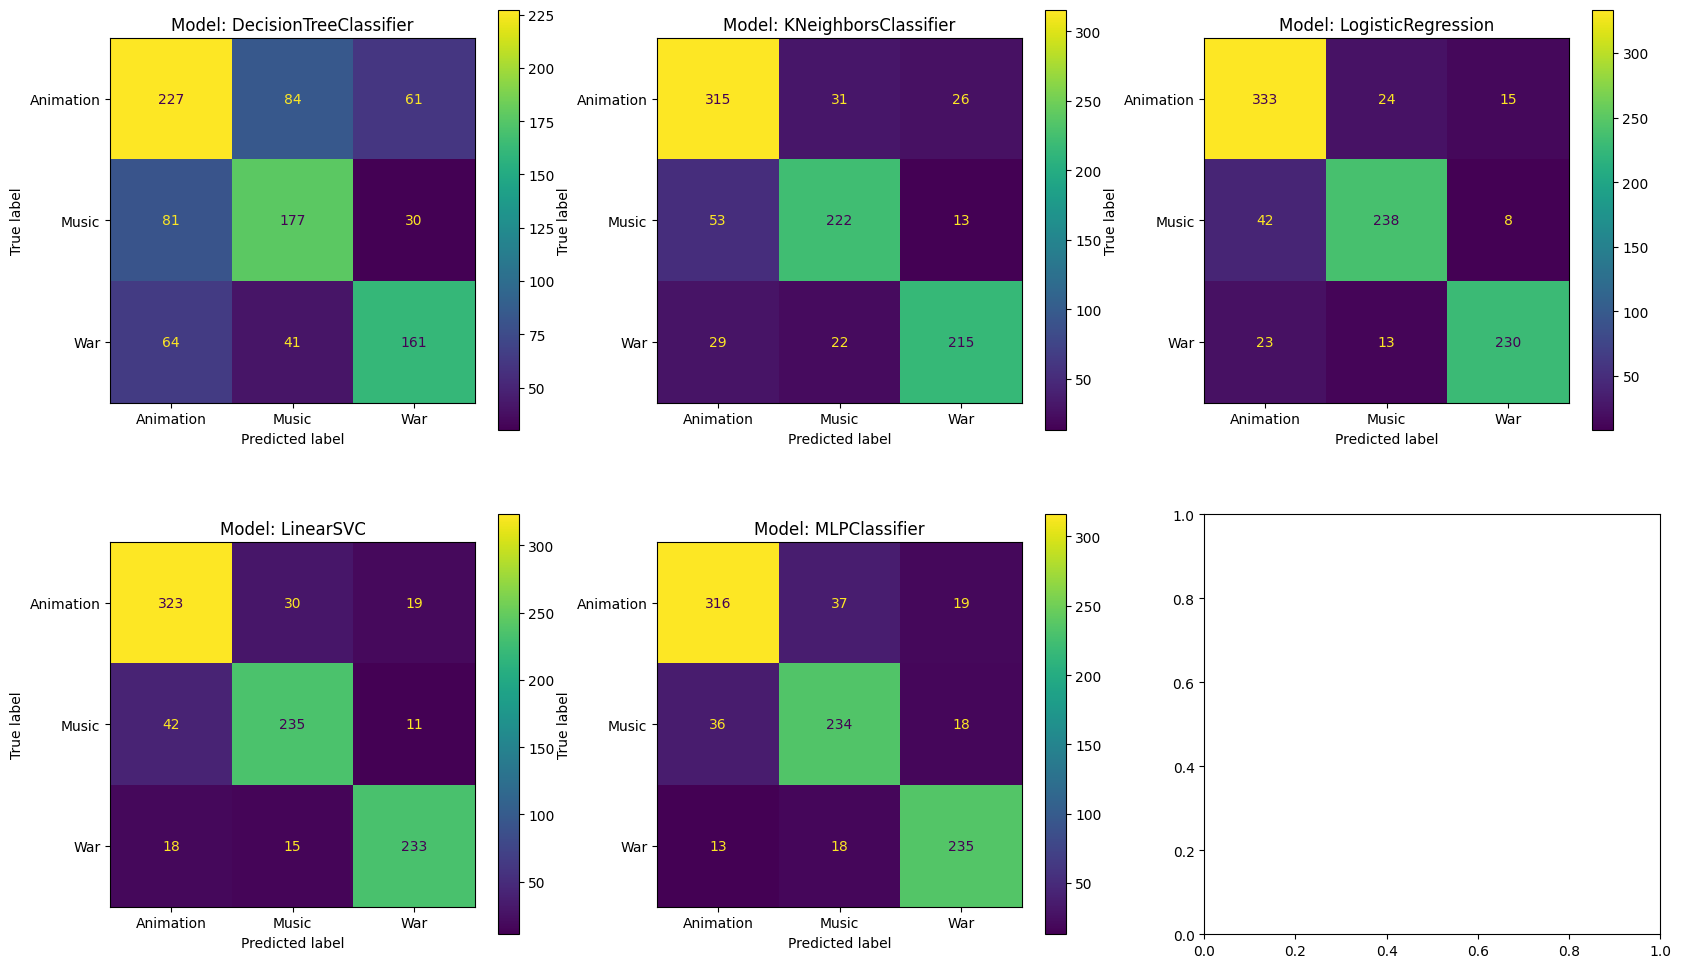

In [27]:
plot_confusion_matrices(fitted_classifiers)

## A more complex model


We will now train 4 models on more features, 2 of them will by using Tf-Idf for the overview feature and 2 the pretrained embeddings.

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            45466 non-null  object 
 1   genres        45466 non-null  object 
 2   budget        45466 non-null  object 
 3   overview      44512 non-null  object 
 4   popularity    45461 non-null  object 
 5   revenue       45460 non-null  float64
 6   runtime       45203 non-null  float64
 7   vote_average  45460 non-null  float64
 8   vote_count    45460 non-null  float64
dtypes: float64(4), object(5)
memory usage: 3.1+ MB


We define `preprocess_data` to preprocess our data.

In [29]:
def preprocess_data(data, target_genres):
    # genres
    data.loc[:, 'genres'] = data['genres'].apply(literal_eval)
    data.loc[:, 'genres'] = data['genres'].apply(lambda genre_list: [dictionary.get('name') for dictionary in genre_list])
    data = data.explode('genres')
    data = data[data['genres'].isin(target_genres)]
    data = data[data.groupby('id')['genres'].transform('nunique')==1]

    # budget
    data['budget'] = pd.to_numeric(data['budget'])

    # popularity
    data['popularity'] = pd.to_numeric(data['popularity'])

    # vote_count
    data['vote_count'] = data['vote_count'].infer_objects()

    data = data.drop(columns=['id'])
    return data.dropna()

In [30]:
data = preprocess_data(data.copy(), ['War','Animation', 'Music'])

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4629 entries, 0 to 45449
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   genres        4629 non-null   object 
 1   budget        4629 non-null   int64  
 2   overview      4629 non-null   object 
 3   popularity    4629 non-null   float64
 4   revenue       4629 non-null   float64
 5   runtime       4629 non-null   float64
 6   vote_average  4629 non-null   float64
 7   vote_count    4629 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 325.5+ KB


In order to seperate the numerical and categorical features, and generally to apply different transformations to data features, we will use different pipelines, one for each transformation type we want to use. In the end, we combine them by using `ColumnTransformer` and putting it together with a classifier in the final pipeline.

In [34]:
numerical = data.select_dtypes(exclude=['object']).columns.to_list()

text = ['overview']

print(numerical, categorical, text)

['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count'] ['genres', 'overview'] ['overview']


We create the functions `build_model_pipeline` and `evaluate_clf_cv` to build models with their pipelines and then evaluate them by using cross validation.

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer

def build_model_pipeline(model, feat_extraction_method):
  numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
  ])

  text_transformer = Pipeline(steps=[
    ('squeezer', FunctionTransformer(lambda x: np.array(x).ravel(), accept_sparse=True)),
    ('vectorizer', feat_extraction_method)
  ])

  preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical),
    ('text', text_transformer, text)
  ])

  return Pipeline([
      ('preprocessor', preprocessor),
      ('clf', model)
  ])

def evaluate_clf_cv(feat_extraction, clfs=clfs, X_train=X_train, y_train=y_train):
  for clf in clfs:
    for method in feat_extraction:
        cv_score = cross_val_score(
          estimator=build_model_pipeline(model=clf, feat_extraction_method=method),
          X=X_train,
          y=y_train,
          cv=5
        )

        print(f'{clf.__class__.__name__} 5-fold cv score: {cv_score}, mean score: {np.mean(cv_score)}')

We split our data into train and test.

In [37]:
X, y = data.drop(columns=['genres']), data['genres']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3703, 7) (926, 7) (3703,) (926,)


Since *exetastikh*, the bug could not be resolved. If fixed, it would be great. From running some models seperately we observed better scores, but these are not shown on the notebook.

In [38]:
clfs = [
  LogisticRegression(random_state=seed),
  LinearSVC(random_state=seed)
]

feat_extraction = [
    TfidfVectorizer(max_features=5000, stop_words='english'),
    Word2VecVectorizer(pretrained_w2v)
]

evaluate_clf_cv(feat_extraction, clfs)

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 588, in _fit
 